# Notebook 6 (V02) — Correlation Analysis

**Objective.** Test whether the plant's bioelectric signal co-varies with the
signals used elsewhere in this project — ambient **CO₂**, participant
**HRV**, and participant **facial expression (FER)** — using a single,
consistent statistical method. For HRV and FER this covers both the raw,
independently-measured signal and the specific derived signal that
`02_emotion_labelling.ipynb` actually thresholds into the ML targets
(`arousal_level`, `valence_direction`), so the analysis speaks directly to
whether the plant signal used for **prediction** relates to the signals used
for **label classification**.


## 1  Configuration

All paths, thresholds and column names used throughout the notebook are
defined here. The reference-signal columns (CO₂, HRV, FER) are *resolved*
against the dataset header in Section 2 — nothing is assumed or invented.


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown

try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False
    print("xgboost not installed - the Top-5 feature ranking will use Random Forest only.")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- paths -------------------------------------------------------------
DATASET_CSV = Path("../data/datasets/consolidated_dataset.csv")   # output of Notebook 1
OUTPUT_CSV  = Path("../data/datasets/correlation_analysis_results.csv")

# --- statistics ----------------------------------------------------------
ALPHA          = 0.05        # significance threshold for every test
LAG_RANGE      = range(1, 6)  # test lags of 1-5 windows (windows are 30 s)
ROLLING_WINDOW = 5            # window count for the rolling std variant (~2.5 min)

# --- candidate column names, resolved against the header in Section 2 ---
HRV_COL         = "rmssd"        # primary, directly-measured HRV marker (Notebook 2, "primary
                                   # time-domain HRV marker") - raw, not itself read by the label rule
AROUSAL_HRV_COL = "arousal_hrv"  # the actual arousal_level determinant (Notebook 2 §4.7): a per-session
                                   # z-score combining rmssd + mean HR. Derived, but computed purely from
                                   # participant ECG - independent of the plant signal, so correlating it
                                   # here is not circular.
CO2_CANDIDATES  = ["co2", "co2_ppm", "CO2", "co2_concentration"]
FER_CANDIDATES  = ["fer_valence"]   # sole FER signal read by the label rule (-> valence_direction).
                                     # fer_arousal is exported by Notebook 2 for inspection only, is never
                                     # used to build any label, and is excluded here entirely - not
                                     # resolved, not tested, not reported.

# Candidate plant features (spreadsheet columns Q-AL), mirrored from the
# feature set used by the three ML pipelines (04_01/02/03_ml_pipeline_*).
# Only columns that are actually present *and* vary are used further down.
PLANT_CANDIDATE_FEATURES = [
    "plant_mean", "plant_median", "plant_std", "plant_detrend_std", "plant_iqr",
    "plant_min", "plant_max", "plant_range", "plant_rms", "plant_zcr",
    "plant_sat_pos_frac", "plant_sat_neg_frac", "plant_const_flag",
    "bp_0_1", "bp_1_5", "bp_5_15", "bp_15_30", "band_power_sum",
    "plant_dead_flag", "plant_suspect_flag",
]

# Classification targets used by the three ML pipelines - used below only to
# rank plant-feature importance, never as correlation inputs themselves.
ML_PIPELINE_TARGETS = ["label", "arousal_level", "valence_direction"]

print(f"Dataset: {DATASET_CSV.resolve()}")
print(f"Output : {OUTPUT_CSV.resolve()}")


Dataset: C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\datasets\consolidated_dataset.csv
Output : C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\datasets\correlation_analysis_results.csv


## 2  Data Loading & Column Resolution

We load the consolidated dataset and resolve the reference-signal columns
against its actual header. Nothing is hard-coded that isn't confirmed to
exist in the data.


In [2]:
df = pd.read_csv(DATASET_CSV)
print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns "
      f"from {df['session_id'].nunique()} sessions / {df['participant_id'].nunique()} participants")

assert HRV_COL in df.columns, f"expected HRV column '{HRV_COL}' not found in dataset"
assert AROUSAL_HRV_COL in df.columns, f"expected arousal-label column '{AROUSAL_HRV_COL}' not found in dataset"

CO2_COL = next((c for c in CO2_CANDIDATES if c in df.columns), None)
FER_COLS = [c for c in FER_CANDIDATES if c in df.columns]

resolved = {
    "CO2 column":                     CO2_COL if CO2_COL else "NOT FOUND - CO2 analysis will be skipped",
    "HRV column (raw)":               HRV_COL,
    "HRV column (label determinant)": AROUSAL_HRV_COL,
    "FER column (label determinant)":                  ", ".join(FER_COLS) if FER_COLS else "NOT FOUND",
}
display(Markdown("**Columns resolved from the dataset header:**\n\n" +
                  "\n".join(f"- **{k}:** `{v}`" for k, v in resolved.items())))


Loaded 284 rows x 83 columns from 15 sessions / 15 participants


**Columns resolved from the dataset header:**

- **CO2 column:** `co2`
- **HRV column (raw):** `rmssd`
- **HRV column (label determinant):** `arousal_hrv`
- **FER column (label determinant):** `fer_valence`

CO₂ is streamed live during recording and aggregated per window in
`02_emotion_labelling.ipynb` (§4.6b) as environmental context — mean, std,
sample count and a quality flag per window (`co2`, `co2_std`,
`co2_n_samples`, `co2_quality`). It is exported into the consolidated
dataset alongside the other per-window columns but, like HRV and FER, is
never a candidate feature for the classifiers in `04_01/02/03`. Its only
consumer is the CO2 ↔ Plant analysis below.


## 3  Plant Signal: Top-5 Features (dynamic, from the ML pipelines)

The three ML pipelines (`04_01_ml_pipeline_emotion`, `04_02_ml_pipeline_arousal`,
`04_03_ml_pipeline_valence`) each train a Random Forest and an XGBoost
classifier on the plant features to predict `label`, `arousal_level` and
`valence_direction` respectively, and expose `feature_importances_`.

Rather than hard-coding a Top-5 list, this cell **re-trains the same kind of
models on the current dataset** (same candidate plant-feature set, same three
targets) and ranks features by their mean importance across all
target/model combinations. If the plant feature set or the dataset changes
upstream, re-running this cell automatically updates the Top-5 used for the
rest of the notebook — nothing here is pinned by hand.


In [3]:
candidate_feats = [c for c in PLANT_CANDIDATE_FEATURES if c in df.columns]
nunique = df[candidate_feats].nunique()
candidate_feats = [c for c in candidate_feats if nunique[c] > 1]   # drop constant columns

X = df[candidate_feats].apply(pd.to_numeric, errors="coerce")
X = X.fillna(X.median(numeric_only=True))

importances = []
for target in ML_PIPELINE_TARGETS:
    y = df[target].astype(str)
    rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    rf.fit(X, y)
    importances.append(pd.Series(rf.feature_importances_, index=candidate_feats, name=f"RF_{target}"))

    if XGBOOST_OK:
        y_enc = LabelEncoder().fit_transform(y)
        xgb = XGBClassifier(n_estimators=300, random_state=RANDOM_STATE,
                             eval_metric="mlogloss", verbosity=0)
        xgb.fit(X, y_enc)
        importances.append(pd.Series(xgb.feature_importances_, index=candidate_feats, name=f"XGB_{target}"))

importance_df = pd.concat(importances, axis=1)
importance_df["mean_importance"] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values("mean_importance", ascending=False)

TOP5_PLANT_FEATURES = importance_df.head(5).index.tolist()

display(importance_df.round(3))
display(Markdown(
    f"**Selected Top-5 plant features (mean importance across "
    f"{importance_df.shape[1]-1} RF/XGBoost models over the three ML-pipeline "
    f"targets):** `{TOP5_PLANT_FEATURES}`\n\n"
    "These five features are used as *the* plant signal throughout the rest "
    "of this notebook."
))


,RF_label,XGB_label,RF_arousal_level,XGB_arousal_level,RF_valence_direction,XGB_valence_direction,mean_importance
plant_max,0.074,0.070,0.083,0.073,0.088,0.090,0.080
plant_median,0.078,0.083,0.077,0.057,0.067,0.076,0.073
plant_range,0.079,0.079,0.069,0.067,0.072,0.066,0.072
plant_mean,0.060,0.074,0.068,0.082,0.063,0.080,0.071
plant_min,0.083,0.063,0.072,0.059,0.083,0.061,0.070
plant_zcr,0.072,0.057,0.071,0.077,0.066,0.075,0.070
plant_iqr,0.068,0.066,0.074,0.085,0.065,0.057,0.069
bp_5_15,0.064,0.075,0.062,0.070,0.067,0.061,0.066
plant_std,0.060,0.060,0.059,0.082,0.059,0.062,0.064
bp_1_5,0.071,0.063,0.062,0.056,0.062,0.068,0.063


**Selected Top-5 plant features (mean importance across 6 RF/XGBoost models over the three ML-pipeline targets):** `['plant_max', 'plant_median', 'plant_range', 'plant_mean', 'plant_min']`

These five features are used as *the* plant signal throughout the rest of this notebook.

## 4  Methodology

**Four analyses**, each against the plant signal (Top-5 features):

1. **CO₂ ↔ Plant** — does ambient CO₂ co-vary with the plant signal?
2. **HRV (RMSSD, raw) ↔ Plant** — does the raw, directly-measured HRV marker co-vary with the plant signal?
3. **HRV (arousal_hrv, label determinant) ↔ Plant** — does the actual composite
   signal that `02_emotion_labelling.ipynb` thresholds into `arousal_level`
   (§4.7) co-vary with the plant signal?
4. **FER (fer_valence, label determinant) ↔ Plant** — does the sole FER
   signal that `02_emotion_labelling.ipynb` thresholds into
   `valence_direction` co-vary with the plant signal?

`fer_arousal` is excluded from every analysis in this notebook: Notebook 2
exports it for inspection only and its label rule never reads it (§4.7), so
it plays no role in either the ML targets or this correlation study.

**Three variants** per analysis:

1. **Raw** — Spearman correlation of the raw per-window values.
2. **Standard deviation** — Spearman correlation of a rolling, per-session
   standard deviation (window size `ROLLING_WINDOW`) of each signal — tests
   whether the two signals co-vary in their *variability*, not just their level.
3. **Lag** — Spearman correlation between the reference signal and the plant
   signal at lags of 1-5 windows (reference signal shifted forward within
   each session); the strongest absolute ρ and its lag are reported — tests
   whether the plant reacts to the reference signal with a delay.

**Why Spearman, and only Spearman.** Spearman's ρ is rank-based, makes no
assumption of normality, and is robust to outliers — a good uniform choice
across CO₂, HRV and FER signals without needing per-signal method selection.
No Pearson, no Kendall, no normality testing.

**Why these signals, and not model outputs.** Model outputs (the trained
classifiers' predictions) are *derived from* the plant data itself —
correlating them with the plant signal again would be circular. Every
signal tested here is independent of the plant instead: CO₂ and RMSSD are
directly measured, and `arousal_hrv` / `fer_valence` are derived signals,
but derived *only* from participant ECG and camera data respectively —
never from the plant — so testing them is not circular. Testing both the
raw marker and the label-determinant signal for HRV shows whether the
project's calibration/thresholding step (per-session median/MAD z-scoring,
§4.7 of Notebook 2) changes the relationship with the plant signal relative
to the untransformed marker.

**Note on feature selection.** The Top-5 plant features (Section 3) are
chosen by predictive importance for `label` / `arousal_level` /
`valence_direction`, which are themselves built from `arousal_hrv` and
`fer_valence`. This is a mild double-use of information: it does not
invalidate the correlations below (importances only decide *which* plant
features are looked at — they play no part in computing the ρ values
themselves, which are fresh Spearman tests on raw values), but it does mean
the Top-5 set is not chosen independently of the reference signals tested
in Sections 7-8. A high Top-5 ranking should not be read as presupposing a
strong correlation here — the ρ values below can, and do, come out small or
non-significant despite a feature's high classifier importance.

**Independence note.** HRV and FER are recorded by entirely separate sensors
(chest strap vs. camera) and are not derived from one another, which makes
the two HRV analyses and the FER analysis the scientifically cleanest of
this notebook. CO₂ is also independent of the plant signal and, per Section 2,
is exported into this dataset and tested here as well.

Every test reports ρ, p-value and n; ρ is considered significant at
α = `ALPHA`.


## 5  Shared Analysis Helper

One function runs a single Spearman variant (raw / std / lag) between a
reference column and each of the Top-5 plant features. All rolling and lag
operations are computed **per session** (`groupby("session_id")`) so that
windows are never compared across different recordings/participants.


In [4]:
def _rolling_std(series_by_session, window):
    return series_by_session.transform(lambda s: s.rolling(window, min_periods=window).std())


def _shift(series_by_session, lag):
    return series_by_session.transform(lambda s: s.shift(lag))


def analyze_pair(data, ref_col, plant_features, variant, window=ROLLING_WINDOW, lags=LAG_RANGE):
    # Run one Spearman variant (raw/std/lag) between ref_col and each plant feature.
    # Returns a results DataFrame (one row per plant feature) and, for the lag
    # variant, a dict of per-feature {lag: rho} curves for plotting.
    rows, lag_curves = [], {}

    for feat in plant_features:
        if variant == "raw":
            sub = data[[ref_col, feat]].dropna()
            rho, p, n = (*spearmanr(sub[ref_col], sub[feat]), len(sub)) if len(sub) >= 3 else (np.nan, np.nan, len(sub))
            rows.append(dict(plant_feature=feat, rho=rho, p_value=p, n=n, best_lag=np.nan))

        elif variant == "std":
            x_std = _rolling_std(data.groupby("session_id")[ref_col], window)
            y_std = _rolling_std(data.groupby("session_id")[feat], window)
            sub = pd.DataFrame({"x": x_std, "y": y_std}).dropna()
            rho, p, n = (*spearmanr(sub["x"], sub["y"]), len(sub)) if len(sub) >= 3 else (np.nan, np.nan, len(sub))
            rows.append(dict(plant_feature=feat, rho=rho, p_value=p, n=n, best_lag=np.nan))

        elif variant == "lag":
            curve = []
            for lag in lags:
                shifted_ref = _shift(data.groupby("session_id")[ref_col], lag)
                sub = pd.DataFrame({"x": shifted_ref, "y": data[feat]}).dropna()
                if len(sub) >= 3:
                    rho, p = spearmanr(sub["x"], sub["y"])
                    curve.append(dict(lag=lag, rho=rho, p_value=p, n=len(sub)))
            curve_df = pd.DataFrame(curve)
            lag_curves[feat] = curve_df
            if len(curve_df):
                best = curve_df.loc[curve_df["rho"].abs().idxmax()]
                rows.append(dict(plant_feature=feat, rho=best["rho"], p_value=best["p_value"],
                                  n=int(best["n"]), best_lag=int(best["lag"])))
            else:
                rows.append(dict(plant_feature=feat, rho=np.nan, p_value=np.nan, n=0, best_lag=np.nan))
        else:
            raise ValueError(f"unknown variant: {variant}")

    return pd.DataFrame(rows), lag_curves


def plot_raw(data, ref_col, ref_label, plant_features, res_raw):
    fig, axes = plt.subplots(1, len(plant_features), figsize=(3.4 * len(plant_features), 3.2))
    for ax, feat in zip(axes, plant_features):
        sub = data[[ref_col, feat]].dropna()
        sns.regplot(x=ref_col, y=feat, data=sub, ax=ax,
                     scatter_kws=dict(s=12, alpha=0.5), line_kws=dict(color="crimson"))
        rho = res_raw.loc[res_raw.plant_feature == feat, "rho"].values[0]
        ax.set_title(f"{feat}\nρ={rho:.2f}", fontsize=10)
        ax.set_xlabel(ref_label, fontsize=9)
    fig.suptitle(f"{ref_label} vs. Plant Top-5 (raw)")
    plt.tight_layout()
    plt.show()


def plot_lag(lag_curves, ref_label):
    fig, ax = plt.subplots(figsize=(6, 4))
    for feat, curve in lag_curves.items():
        if len(curve):
            ax.plot(curve["lag"], curve["rho"], marker="o", label=feat)
    ax.axhline(0, color="grey", lw=0.8)
    ax.set_xlabel("Lag (windows, 30 s each)")
    ax.set_ylabel("Spearman ρ")
    ax.set_title(f"{ref_label} -> Plant: ρ across lags 1-5")
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


def run_section(data, ref_col, ref_label, plant_features, window=ROLLING_WINDOW, lags=LAG_RANGE, alpha=ALPHA):
    # Run all three variants for one reference signal, print + plot, return tidy results.
    print(f"\n=== {ref_label} <-> Plant (Top-5) ===")
    all_rows = []
    for variant in ["raw", "std", "lag"]:
        res, lag_curves = analyze_pair(data, ref_col, plant_features, variant, window, lags)
        res.insert(0, "variant", variant)
        res.insert(0, "analysis", ref_label)
        res["significant"] = res["p_value"] < alpha
        all_rows.append(res)

        mean_abs_rho = res["rho"].abs().mean()
        print(f"\n[{variant}] mean |ρ| across 5 features = {mean_abs_rho:.3f}")
        print(res.drop(columns=["analysis", "variant"]).to_string(index=False))

        if variant == "raw":
            plot_raw(data, ref_col, ref_label, plant_features, res)
        elif variant == "lag":
            plot_lag(lag_curves, ref_label)

    return pd.concat(all_rows, ignore_index=True)


## 6  Analysis 1 — CO₂ ↔ Plant

Ambient CO₂ is aggregated per window in `02_emotion_labelling.ipynb` (§4.6b)
and resolved automatically against the dataset header in §2 (`CO2_COL`).



=== CO2 <-> Plant (Top-5) ===

[raw] mean |ρ| across 5 features = 0.243
plant_feature       rho      p_value   n  best_lag  significant
    plant_max -0.037243 5.319205e-01 284       NaN        False
 plant_median  0.468295 6.931857e-17 284       NaN         True
  plant_range -0.089874 1.307971e-01 284       NaN        False
   plant_mean  0.497089 3.941372e-19 284       NaN         True
    plant_min  0.121538 4.068211e-02 284       NaN         True


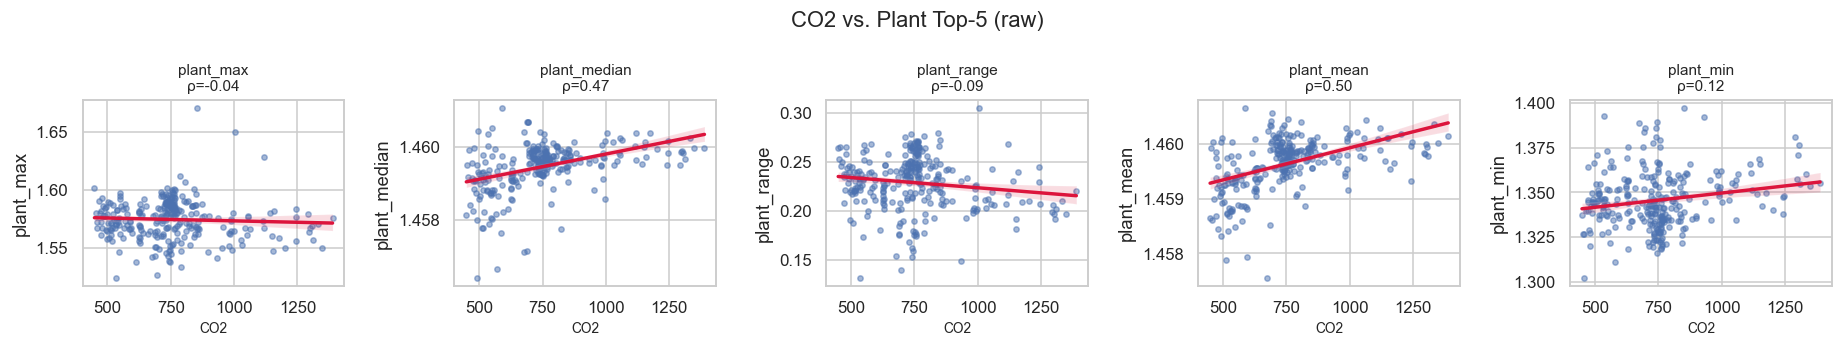


[std] mean |ρ| across 5 features = 0.115
plant_feature       rho  p_value   n  best_lag  significant
    plant_max  0.060506 0.367412 224       NaN        False
 plant_median  0.240265 0.000284 224       NaN         True
  plant_range  0.047796 0.476617 224       NaN        False
   plant_mean  0.127525 0.056685 224       NaN        False
    plant_min -0.101090 0.131457 224       NaN        False

[lag] mean |ρ| across 5 features = 0.245
plant_feature       rho      p_value   n  best_lag  significant
    plant_max -0.061724 3.420457e-01 239         3        False
 plant_median  0.454694 3.945186e-15 269         1         True
  plant_range -0.096612 1.139074e-01 269         1        False
   plant_mean  0.503292 1.113247e-18 269         1         True
    plant_min  0.108260 1.061008e-01 224         4        False


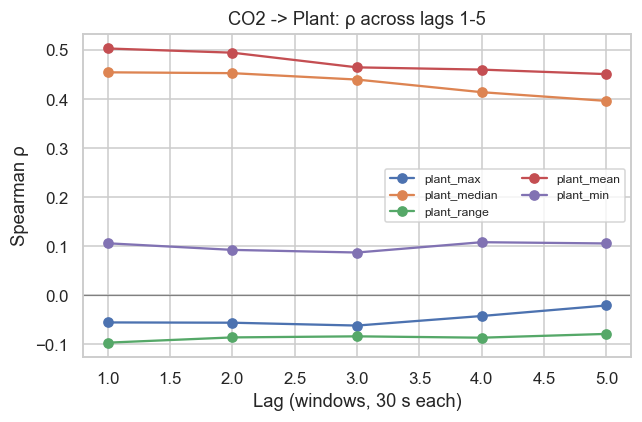

In [5]:
if CO2_COL is None:
    print("CO2 column not found in the consolidated dataset - skipping CO2 <-> Plant analysis.")
    results_co2 = pd.DataFrame(columns=["analysis", "variant", "plant_feature", "rho", "p_value", "n", "best_lag", "significant"])
else:
    results_co2 = run_section(df, CO2_COL, "CO2", TOP5_PLANT_FEATURES)


## 7  Analysis 2 — HRV ↔ Plant

Two HRV signals are tested against the plant Top-5, both independent of the
plant:

- **`rmssd` (raw)** — the project's primary time-domain HRV marker
  (Notebook 2), a directly-measured ECG-derived quantity, used as-is.
- **`arousal_hrv` (label determinant)** — the actual signal
  `02_emotion_labelling.ipynb` thresholds into `arousal_level` (§4.7): a
  per-session z-score combining RMSSD and mean HR
  (`arousal_hrv = (-z_rmssd + z_hr) / 2`). It is derived, but built purely
  from participant ECG with per-session calibration - it never touches the
  plant signal - so it is legitimate to correlate here, and it directly
  answers whether the signal that actually produced the `arousal_level`
  label co-varies with the plant features used to predict that same label.



=== HRV (RMSSD, raw) <-> Plant (Top-5) ===

[raw] mean |ρ| across 5 features = 0.072
plant_feature       rho  p_value   n  best_lag  significant
    plant_max -0.063788 0.284020 284       NaN        False
 plant_median -0.079499 0.181565 284       NaN        False
  plant_range -0.051684 0.385542 284       NaN        False
   plant_mean -0.116735 0.049380 284       NaN         True
    plant_min  0.048461 0.415900 284       NaN        False


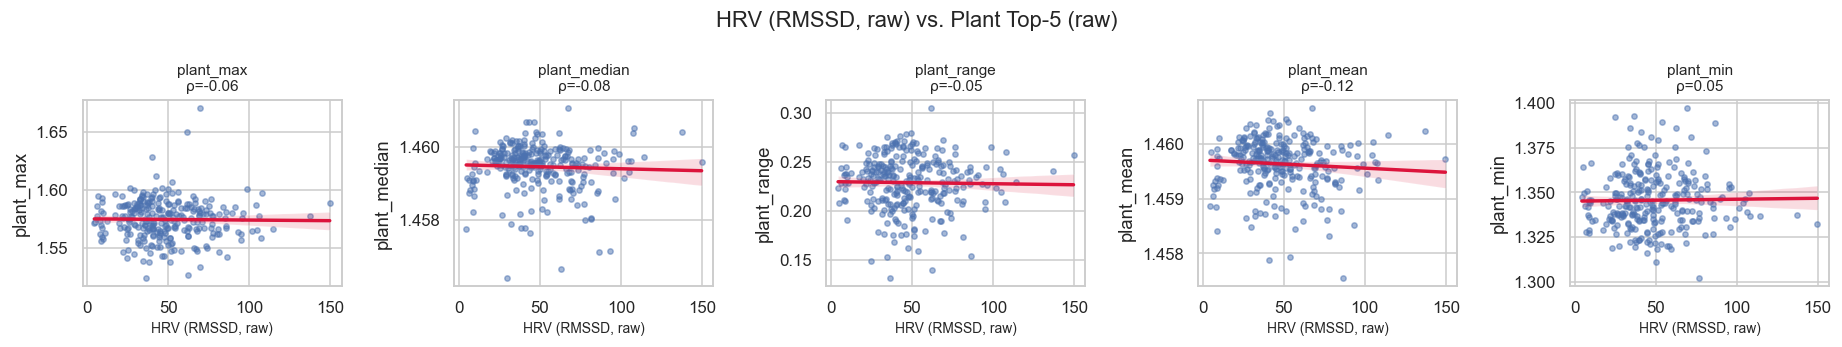


[std] mean |ρ| across 5 features = 0.051
plant_feature       rho  p_value   n  best_lag  significant
    plant_max  0.097850 0.144347 224       NaN        False
 plant_median -0.019574 0.770787 224       NaN        False
  plant_range  0.006635 0.921342 224       NaN        False
   plant_mean  0.001036 0.987702 224       NaN        False
    plant_min -0.129293 0.053313 224       NaN        False

[lag] mean |ρ| across 5 features = 0.115
plant_feature       rho  p_value   n  best_lag  significant
    plant_max -0.070524 0.310246 209         5        False
 plant_median -0.157051 0.018673 224         4         True
  plant_range -0.060557 0.322421 269         1        False
   plant_mean -0.180518 0.005124 239         3         True
    plant_min  0.104800 0.095597 254         2        False


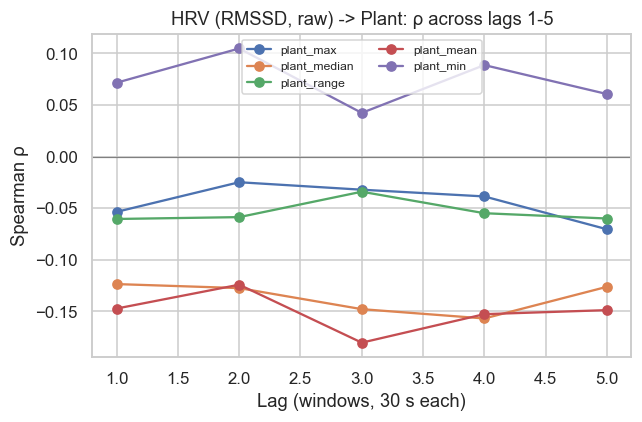


=== HRV (arousal_hrv, label determinant) <-> Plant (Top-5) ===

[raw] mean |ρ| across 5 features = 0.024
plant_feature       rho  p_value   n  best_lag  significant
    plant_max  0.010441 0.860933 284       NaN        False
 plant_median  0.038253 0.520850 284       NaN        False
  plant_range  0.024894 0.676137 284       NaN        False
   plant_mean  0.025743 0.665756 284       NaN        False
    plant_min -0.018958 0.750400 284       NaN        False


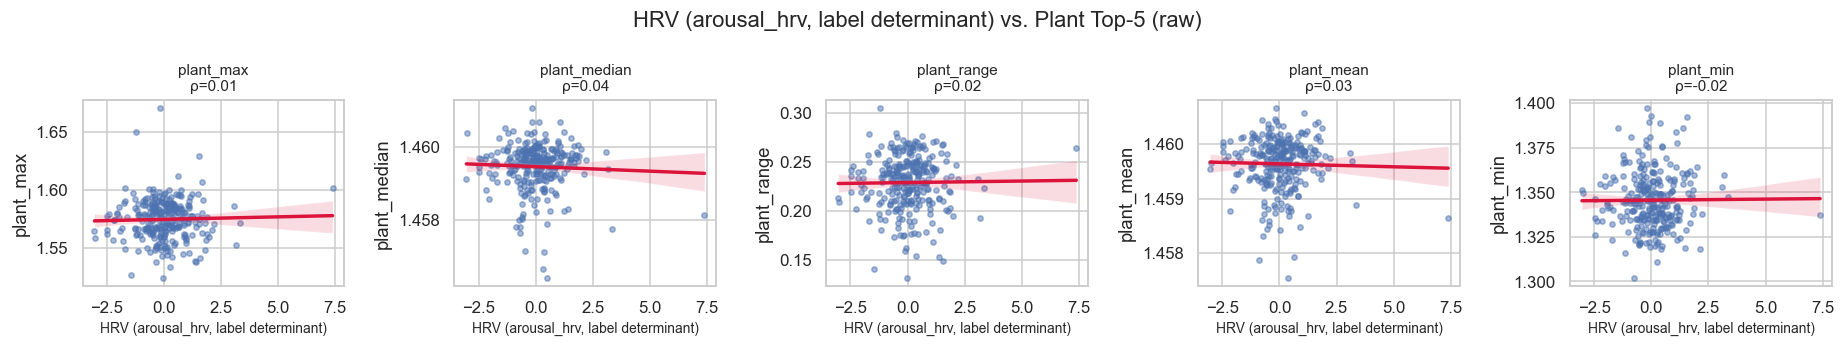


[std] mean |ρ| across 5 features = 0.079
plant_feature       rho  p_value   n  best_lag  significant
    plant_max  0.108834 0.104249 224       NaN        False
 plant_median  0.003599 0.957281 224       NaN        False
  plant_range  0.149119 0.025627 224       NaN         True
   plant_mean -0.075238 0.262139 224       NaN        False
    plant_min -0.057498 0.391748 224       NaN        False

[lag] mean |ρ| across 5 features = 0.059
plant_feature       rho  p_value   n  best_lag  significant
    plant_max  0.072703 0.295498 209         5        False
 plant_median  0.072086 0.238665 269         1        False
  plant_range  0.033227 0.632926 209         5        False
   plant_mean -0.061531 0.328700 254         2        False
    plant_min -0.057468 0.347769 269         1        False


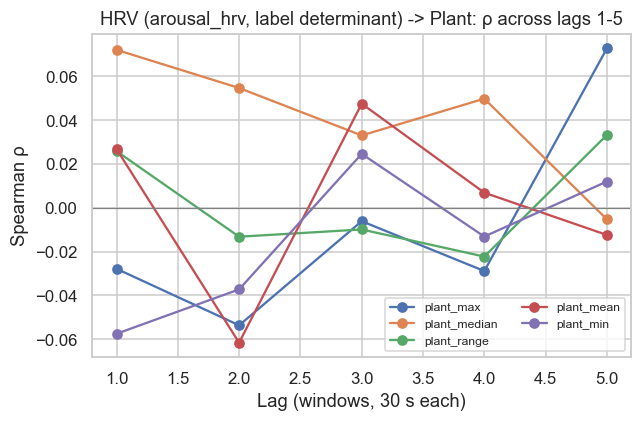

In [6]:
results_hrv_raw     = run_section(df, HRV_COL, "HRV (RMSSD, raw)", TOP5_PLANT_FEATURES)
results_hrv_arousal = run_section(df, AROUSAL_HRV_COL, "HRV (arousal_hrv, label determinant)", TOP5_PLANT_FEATURES)
results_hrv = pd.concat([results_hrv_raw, results_hrv_arousal], ignore_index=True)


## 8  Analysis 3 — FER ↔ Plant

Only `fer_valence` is tested: it is the sole FER signal
`02_emotion_labelling.ipynb` reads to build `valence_direction` (§4.7-4.9).

`fer_arousal` is not tested anywhere in this notebook. Notebook 2 exports it
for inspection only and its label rule never reads it, so it has no role in
either the plant-feature ML targets or the emotion labels - including it
here would only add a distractor signal with no statistical justification
for being correlated against the plant.



=== FER (fer_valence, label determinant) <-> Plant (Top-5) ===

[raw] mean |ρ| across 5 features = 0.163
plant_feature       rho  p_value   n  best_lag  significant
    plant_max -0.186318 0.001612 284       NaN         True
 plant_median  0.105304 0.076440 284       NaN        False
  plant_range -0.189611 0.001325 284       NaN         True
   plant_mean  0.152495 0.010064 284       NaN         True
    plant_min  0.183261 0.001928 284       NaN         True


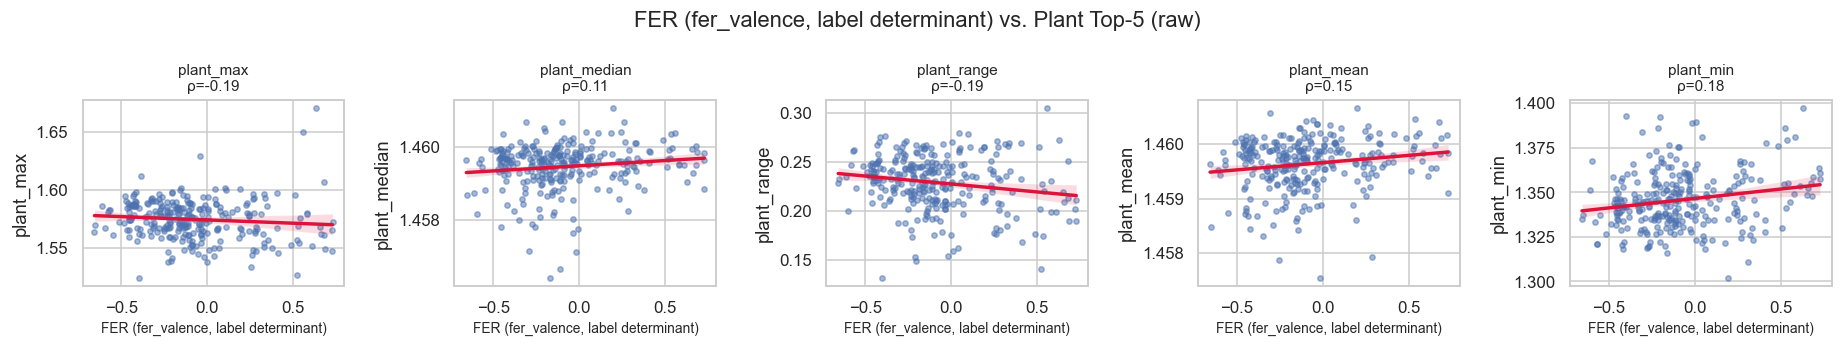


[std] mean |ρ| across 5 features = 0.094
plant_feature       rho  p_value   n  best_lag  significant
    plant_max -0.098268 0.142630 224       NaN        False
 plant_median  0.107499 0.108591 224       NaN        False
  plant_range  0.090759 0.175879 224       NaN        False
   plant_mean  0.128659 0.054503 224       NaN        False
    plant_min -0.046296 0.490577 224       NaN        False

[lag] mean |ρ| across 5 features = 0.185
plant_feature       rho  p_value   n  best_lag  significant
    plant_max -0.220409 0.001342 209         5         True
 plant_median  0.091211 0.135669 269         1        False
  plant_range -0.255517 0.000188 209         5         True
   plant_mean  0.126230 0.038548 269         1         True
    plant_min  0.230894 0.000495 224         4         True


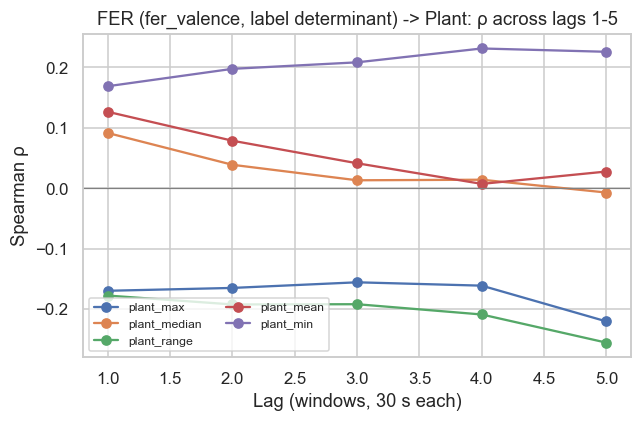

In [7]:
if FER_COLS:
    results_fer = run_section(df, FER_COLS[0], "FER (fer_valence, label determinant)", TOP5_PLANT_FEATURES)
else:
    results_fer = pd.DataFrame(columns=["analysis", "variant", "plant_feature", "rho", "p_value", "n", "best_lag", "significant"])


## 9  Final Summary

All analyses and variants are combined into one tidy table (one row per
plant feature, plus a `MEAN` aggregate row per analysis/variant for a
quick at-a-glance comparison), one comparison figure, and a CSV export.


In [8]:
all_results = pd.concat([results_co2, results_hrv, results_fer], ignore_index=True)

agg_rows = []
for (analysis, variant), grp in all_results.groupby(["analysis", "variant"]):
    agg_rows.append(dict(
        analysis=analysis, variant=variant, plant_feature="MEAN",
        rho=grp["rho"].abs().mean(), p_value=np.nan, n=int(grp["n"].median()),
        best_lag=grp["best_lag"].mode().iloc[0] if grp["best_lag"].notna().any() else np.nan,
        significant=grp["significant"].mean() >= 0.5,
    ))

summary = pd.concat([all_results, pd.DataFrame(agg_rows)], ignore_index=True)
summary = summary.sort_values(["analysis", "variant", "plant_feature"]).reset_index(drop=True)

pd.set_option("display.max_rows", 200)
display(summary)

summary.to_csv(OUTPUT_CSV, index=False)
print(f"\nSaved {len(summary)} rows to {OUTPUT_CSV.resolve()}")


,analysis,variant,plant_feature,rho,p_value,n,best_lag,significant
0,CO2,lag,MEAN,0.244916,NaN,269,1.0,False
1,CO2,lag,plant_max,-0.061724,3.420457e-01,239,3.0,False
2,CO2,lag,plant_mean,0.503292,1.113247e-18,269,1.0,True
3,CO2,lag,plant_median,0.454694,3.945186e-15,269,1.0,True
4,CO2,lag,plant_min,0.108260,1.061008e-01,224,4.0,False
5,CO2,lag,plant_range,-0.096612,1.139074e-01,269,1.0,False
6,CO2,raw,MEAN,0.242808,NaN,284,NaN,True
7,CO2,raw,plant_max,-0.037243,5.319205e-01,284,NaN,False
8,CO2,raw,plant_mean,0.497089,3.941372e-19,284,NaN,True
9,CO2,raw,plant_median,0.468295,6.931857e-17,284,NaN,True



Saved 72 rows to C:\Uni Koeln\COIN_Project\COIN2026_Team-1_Plant-Emotion-Detector\data\datasets\correlation_analysis_results.csv


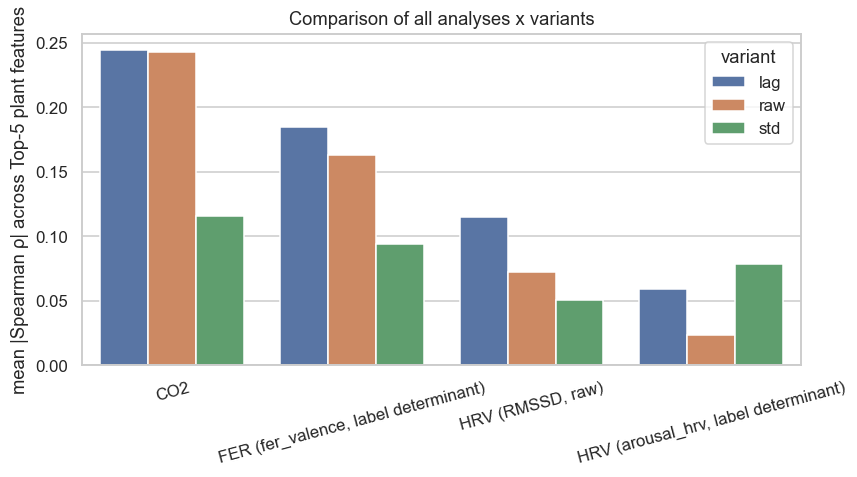

In [9]:
agg = summary[summary["plant_feature"] == "MEAN"].copy()
agg["label"] = agg["analysis"]

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=agg, x="label", y="rho", hue="variant", ax=ax)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("mean |Spearman ρ| across Top-5 plant features")
ax.set_xlabel("")
ax.set_title("Comparison of all analyses x variants")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## 10  Visualization — All Significant Correlations

The MEAN-aggregated comparison above hides *which* individual
(analysis, variant, plant-feature) triples actually reached significance.
This figure lists every one of them explicitly: each bar is a single
Spearman test (one `analysis` × `variant` × plant-feature combination) with
`p_value < ALPHA`, sorted by |ρ|. Bar color encodes only the *sign* of ρ
(blue = positive, vermillion = negative co-variation) — identity of the
analysis/variant/feature is carried by the text label, not by color, so the
two channels are never conflated. `MEAN` rows are excluded here since they
are aggregates, not individual tests, and carry no p-value of their own.


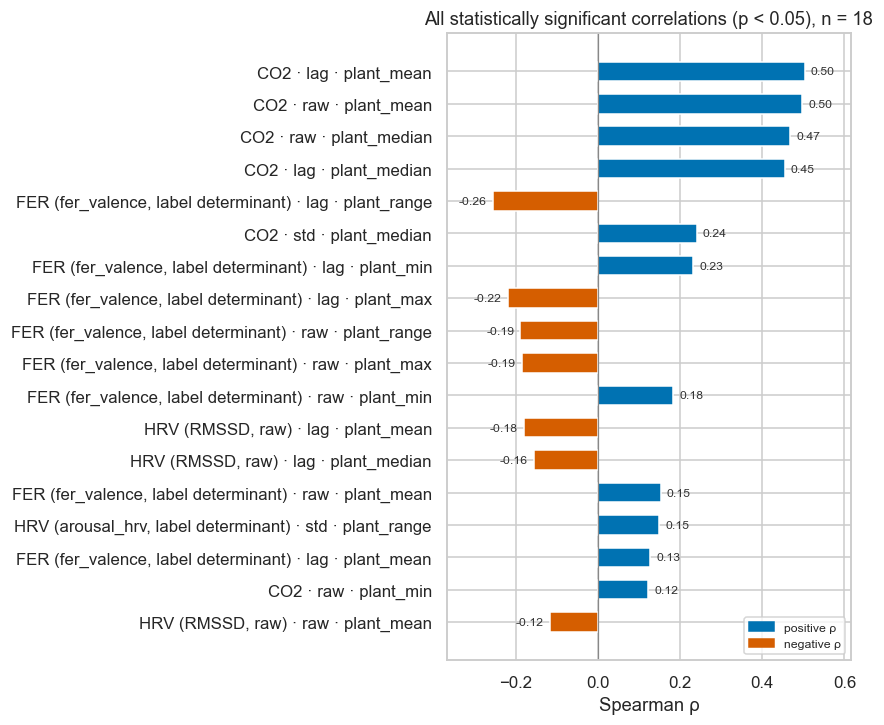

In [10]:
from matplotlib.patches import Patch

sig = (summary[(summary["plant_feature"] != "MEAN") & (summary["significant"])]
       .dropna(subset=["rho"])
       .assign(abs_rho=lambda d: d["rho"].abs())
       .sort_values("abs_rho")
       .reset_index(drop=True))

if sig.empty:
    print(f"No individual (analysis, variant, plant_feature) correlation reached significance at alpha = {ALPHA}.")
else:
    sig["label"] = sig["analysis"] + " · " + sig["variant"] + " · " + sig["plant_feature"]

    POS_COLOR, NEG_COLOR = "#0072B2", "#D55E00"   # Okabe-Ito blue/vermillion - CVD-safe, validated

    fig_h = max(3, 0.32 * len(sig) + 1)
    fig, ax = plt.subplots(figsize=(8, fig_h))
    bars = ax.barh(sig["label"], sig["rho"],
                    color=[POS_COLOR if r >= 0 else NEG_COLOR for r in sig["rho"]], height=0.6)
    ax.axvline(0, color="#888888", lw=0.8)

    for bar, rho in zip(bars, sig["rho"]):
        x = bar.get_width()
        ax.text(x + (0.015 if x >= 0 else -0.015), bar.get_y() + bar.get_height() / 2,
                 f"{rho:.2f}", va="center", ha="left" if x >= 0 else "right",
                 fontsize=8, color="#333333")

    ax.set_xlabel("Spearman ρ")
    ax.set_title(f"All statistically significant correlations (p < {ALPHA}), n = {len(sig)}")
    ax.margins(x=0.15)
    ax.legend(handles=[Patch(color=POS_COLOR, label="positive ρ"), Patch(color=NEG_COLOR, label="negative ρ")],
              loc="lower right", fontsize=8, frameon=True)

    plt.tight_layout()
    plt.show()


## 11  Discussion

None of the analyses above correlate the plant signal with a *model output*
— every ρ reflects a direct relationship between a signal that is
independent of the plant (measured directly, or derived purely from
participant ECG/camera data) and the plant's own bioelectric features, so
any significant result here is not an artefact of how the labels were
constructed.

**HRV (both variants) ↔ Plant** and **FER (fer_valence) ↔ Plant** are the
cleanest tests, since HRV (chest-strap ECG) and FER (camera-based facial
expression) are captured by independent sensors and are not derived from
one another or from the plant. Running both the raw HRV marker (`rmssd`)
and the actual label determinant (`arousal_hrv`) shows whether Notebook 2's
per-session z-scoring/thresholding changes the relationship with the plant
signal relative to the untransformed marker — if the two disagree, that is
itself informative about which stage of the HRV pipeline is (or isn't)
related to the plant. `fer_arousal` is deliberately absent throughout: it
is not read by the label rule, so it was excluded from this analysis rather
than kept in as a distractor.

**CO₂ ↔ Plant** is a plausible-confound check, not a test of an
emotion-predictive relationship: CO₂ is tracked because a rising CO₂ trace
(e.g. participant breathing in a small room) is a plausible physical
explanation for slow plant-voltage drift, not because CO₂ itself is
expected to carry emotion signal. A significant CO₂ ↔ Plant correlation
here would be a reason for caution about the `raw` plant-feature set's
interpretation, not a finding about emotion.

Read the table in Section 9, the significant-correlations figure in
Section 10, and the per-analysis output above together: a low mean |ρ| in
the *raw* variant does not rule out a relationship — check the *std*
variant (co-variability) and the *lag* variant (delayed response) before
concluding a signal pair is unrelated, and check Section 10 for exactly
which feature/variant combinations cleared α. Also keep the Section 4
feature-selection caveat in mind: the Top-5 plant features were themselves
selected using label information built from `arousal_hrv`/`fer_valence`, so
a strong correlation with either signal here is a real, freshly-computed
result, not a foregone conclusion, but the *choice* of which five features
were candidates in the first place was not independent of these reference
signals.
